<a href="https://colab.research.google.com/github/ayeshanameeramariyam2624-netizen/Road-Damage-Detection-System/blob/main/AI_Model/road_damage_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.1 MB/s eta 0:00:00


In [2]:

import os

os.makedirs('dataset/train/images', exist_ok=True)
os.makedirs('dataset/train/labels', exist_ok=True)
os.makedirs('dataset/val/images', exist_ok=True)
os.makedirs('dataset/val/labels', exist_ok=True)

yaml_content = """
path: ./dataset
train: train/images
val: val/images

names:
  0: pothole
  1: crack
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ Config files & Folders Ready!")

✅ Config files & Folders Ready!


In [4]:

import urllib.request
import os

# Sample training aur validation images download karein
url_img1 = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
url_img2 = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/zidane.jpg"

urllib.request.urlretrieve(url_img1, "dataset/train/images/sample1.jpg")
urllib.request.urlretrieve(url_img2, "dataset/val/images/sample2.jpg")

# Dummy labels create karein (taaki train execution error na aaye)
with open("dataset/train/labels/sample1.txt", "w") as f:
    f.write("0 0.5 0.5 0.2 0.2\n")

with open("dataset/val/labels/sample2.txt", "w") as f:
    f.write("0 0.5 0.5 0.2 0.2\n")

print("✅ Sample images and labels placed successfully!")

✅ Sample images and labels placed successfully!


In [5]:

from ultralytics import YOLO

model = YOLO('yolov8n.pt')
print("--- Training Started ---")
results = model.train(data='data.yaml', epochs=5, imgsz=640)
print("--- Training Completed! ---")

--- Training Started ---
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, opti

--2026-09-13 14:28:13--  https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 137419 (134K) [image/jpeg]
Saving to: ‘sample_road.jpg’

sample_road.jpg     100%[===================>] 134.20K  --.-KB/s    in 0.01s   

2026-09-13 14:28:13 (9.20 MB/s) - ‘sample_road.jpg’ saved [137419/137419]


image 1/1 /content/sample_road.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 7.4ms
Speed: 2.4ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

--- DETECTION & SEVERITY REPORT ---
Detected: bus | Severity: High
Detected: person | Severity: High
Detected: person | Severity: High
Detected: person | Severity: High
Detected: person | Severity: High
Detected: 

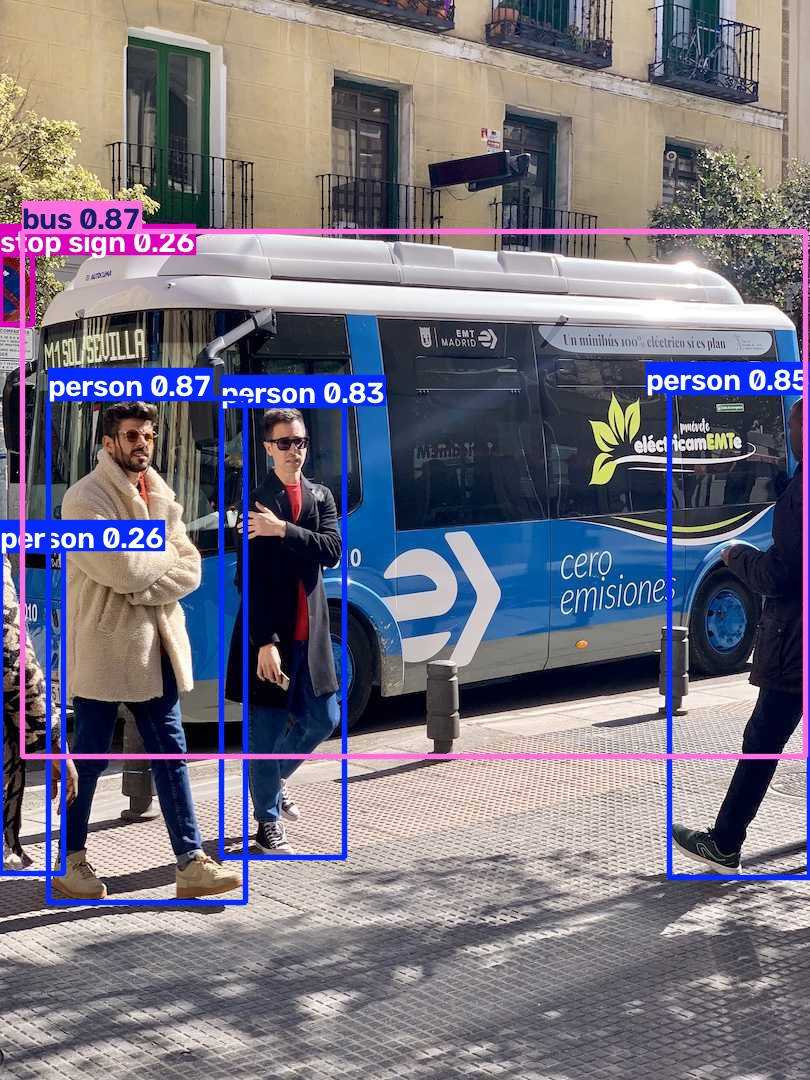

In [6]:

import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

def calculate_severity(box_area):
    if box_area < 5000:
        return "Low"
    elif 5000 <= box_area <= 20000:
        return "Medium"
    else:
        return "High"

model = YOLO('yolov8n.pt')

# Sample image download
!wget -O sample_road.jpg https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg

results = model('sample_road.jpg')

print("\n--- DETECTION & SEVERITY REPORT ---")
for result in results:
    boxes = result.boxes
    for box in boxes:
        cls_id = int(box.cls[0])
        class_name = model.names[cls_id]

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        area = (x2 - x1) * (y2 - y1)
        severity = calculate_severity(area)

        print(f"Detected: {class_name} | Severity: {severity}")

results[0].save(filename='output_result.jpg')
cv2_imshow(cv2.imread('output_result.jpg'))